In [1]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'
import Funciones as Funciones
from NNMF_GIF2 import NNMF_GIF
from pathlib import Path
from ipyfilechooser import FileChooser
import ipywidgets as widgets
from scipy.signal import resample
import os 

from ipywidgets import IntRangeSlider, VBox, HBox, Output,Label
from IPython.display import display, Audio



w_i = []
h_i = []
flujo_ = []
error_i = []
f_ = []

def INF(señal_ovv, fs=8000,fmin=200,fmax=1000,step=1,B=70):
    #b,a   = sig.butter(2, 1000, 'lowpass', fs=fs)
    #señal_ovv_f = sig.filtfilt(b,a,señal_ovv)
    señal_ovv_f = señal_ovv
    frec_formante     = -1
    error_minimo      = np.inf

    for f_i in range(fmin, fmax+1,step):
        Q    = f_i / B
        b, a = sig.iirnotch(w0=f_i/(fs/2), Q=Q)
        flujo_i = sig.filtfilt(b, a, señal_ovv_f)
        w,h = sig.freqz(b,a,fs=fs)
        error = np.sum(np.abs(np.gradient(np.gradient(flujo_i))))       
        if error < error_minimo:
            error_minimo = error
            frec_formante = f_i
        w_i.append(w)
        h_i.append(h)
        flujo_.append(flujo_i)
        error_i.append(error)
        f_.append(f_i) 
    Q = frec_formante / B
    b, a = sig.iirnotch(w0=frec_formante/(fs/2), Q=Q)
    flujo = sig.filtfilt(b, a, señal_ovv_f)

    return flujo,frec_formante,error_minimo,b,a

In [6]:
archivo = 'FN003_A_10'
ruta = Path('Señales AC3E') / 'Femenino' / f'{archivo}.txt'
datos = np.loadtxt(ruta, delimiter='\t', skiprows=1)
fs_r = 8000 
señal_OVV  = datos[:, 2]
to = 0
tf = 50
tiempos       = np.arange(to,tf,1000/fs_r)

In [7]:
flujo_ovv, FF,error,b,a = INF(señal_OVV)

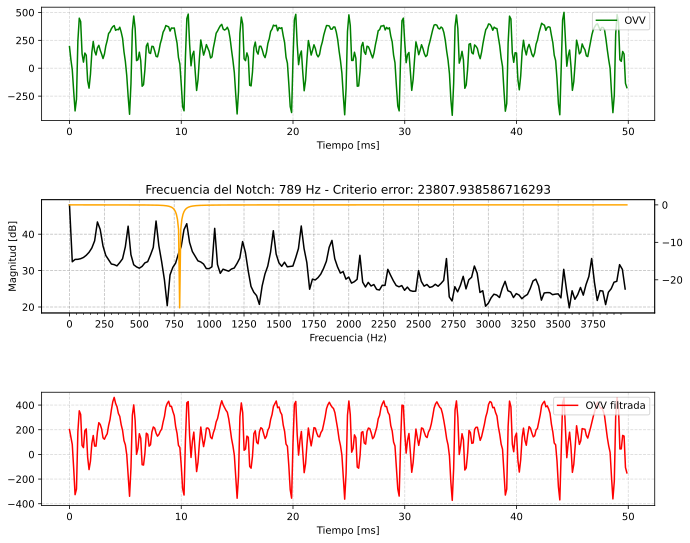

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(11, 9))
ax1_ = ax[1].twinx()
fig.subplots_adjust(hspace=0.7)

ax[0].plot(tiempos, señal_OVV, color='green', label='OVV')
ax[0].legend(loc='upper right')
ax[0].grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
ax[0].set_xlabel('Tiempo [ms]')

fftseñal, fseñal = Funciones.FFT(señal_OVV, fs_r)
ax[1].plot(fseñal, 10*np.log10(abs(fftseñal)), color='k', label='speech')
ax[1].set_xlabel('Frecuencia (Hz)')
ax[1].set_ylabel('Magnitud [dB]')
ax[1].set_title(f'Frecuencia del Notch: {FF} Hz - Criterio error: {error}')
ax[1].set_xticks(np.arange(0,fs_r/2,250))
ax[1].set_xticks(np.arange(0,fs_r/2,50),minor=True)
ax[1].grid(True,linestyle='dashed',color='gray',alpha=0.5)

w,h = sig.freqz(b,a,fs=fs_r)

ax1_.plot(w, 10*np.log10(abs(h)), color='orange')

ax[2].plot(tiempos, flujo_ovv, color='red', label='OVV filtrada')
ax[2].legend(loc='upper right')
ax[2].grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
ax[2].set_xlabel('Tiempo [ms]');

In [9]:
#
slider = widgets.IntSlider(
    value=200,
    min=200,
    max=1000,
    step=1,
    description='Frecuencia:',
    continuous_update=True
)
def graficar(indice):
    indice = indice -200
    fig, ax = plt.subplots(3, 1, figsize=(11, 7))
    ax1_ = ax[1].twinx()
    fig.subplots_adjust(hspace=0.7)


    ax[0].plot(tiempos, señal_OVV, color='green', label='OVV')
    ax[0].legend(loc='upper right')
    ax[0].grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
    ax[0].set_xlabel('Tiempo [ms]')

    fftseñal, fseñal = Funciones.FFT(señal_OVV, fs_r)
    ax[1].plot(fseñal, 10*np.log10(abs(fftseñal)), color='k', label='speech')
    ax[1].set_xlabel('Frecuencia (Hz)')
    ax[1].set_ylabel('Magnitud [dB]')
    ax[1].set_title(f'Frecuencia del Notch: {f_[indice]} Hz - Criterio error: {error_i[indice]}')
    ax[1].set_xticks(np.arange(0,fs_r/2,250))
    ax[1].set_xticks(np.arange(0,fs_r/2,50),minor=True)
    ax[1].grid(True,linestyle='dashed',color='gray',alpha=0.5)
    ax1_.plot(w_i[indice], 10*np.log10(abs(h_i[indice])), color='orange')

    ax[2].plot(tiempos, flujo_[indice], color='red', label='OVV filtrada')
    ax[2].legend(loc='upper right')
    ax[2].grid(True, linestyle='dashed', color='gray', alpha=0.3, which='both')
    ax[2].set_xlabel('Tiempo [ms]')

    plt.show()

out = widgets.interactive_output(graficar, {'indice': slider})
ui = widgets.VBox([slider, out])
display(ui)
